# DengAI: predicting weekly dengue cases

**Goal:** estimate reported dengue cases each week in San Juan, and Iquitos using environmental measurements.

## Load the data and take a first look

In [1]:
import pandas as pd

data = pd.read_csv("data/dengue_features_train.csv")
labels = pd.read_csv("data/dengue_labels_train.csv")
test = pd.read_csv("data/dengue_features_test.csv")

In [2]:
data.shape, labels.shape, test.shape

((1456, 24), (1456, 4), (416, 24))

**1,456 historical weeks**, **416 future weeks**, and **24 input columns**. The labels contain the city-week identifiers and the outcome.

In [3]:
data.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


### The environmental features come from four sources

**1. Weather stations (5 features)**  
Ground stations measure local average, minimum and maximum temperature, daily temperature range, and rainfall. For example, `station_avg_temp_c` describes average station temperature.

**2. Satellite rainfall (1 feature)**  
`precipitation_amt_mm` measures total rainfall in **mm** over a **0.25° × 0.25° grid cell**. It provides an area-based rainfall measurement alongside the station observations.

**3. Climate reanalysis (10 features)**  
Reanalysis combines observations with a weather model to estimate environmental conditions on a consistent grid. The `reanalysis_` columns describe temperature, dew point, humidity and precipitation at **0.5° × 0.5° resolution**. Temperature levels are in **kelvin**, relative humidity in **%**, and specific humidity in **g/kg**. These describe both heat and moisture conditions.

**4. Satellite vegetation (4 features)**  
The **Normalized Difference Vegetation Index (NDVI)** describes vegetation around each city using **0.5° × 0.5° pixels**. The columns `ndvi_ne`, `ndvi_nw`, `ndvi_se` and `ndvi_sw` refer to pixels north-east, north-west, south-east and south-west of the city centre.

| Group | Column names |
|:--|:--|
| Location and time | `city`, `year`, `weekofyear`, `week_start_date` |
| Station temperature | `station_avg_temp_c`, `station_min_temp_c`, `station_max_temp_c`, `station_diur_temp_rng_c` |
| Station and satellite rainfall | `station_precip_mm`, `precipitation_amt_mm` |
| Reanalysis temperature | `reanalysis_air_temp_k`, `reanalysis_avg_temp_k`, `reanalysis_min_air_temp_k`, `reanalysis_max_air_temp_k`, `reanalysis_dew_point_temp_k`, `reanalysis_tdtr_k` |
| Reanalysis humidity | `reanalysis_relative_humidity_percent`, `reanalysis_specific_humidity_g_per_kg` |
| Reanalysis precipitation | `reanalysis_precip_amt_kg_per_m2`, `reanalysis_sat_precip_amt_mm` |
| Vegetation | `ndvi_ne`, `ndvi_nw`, `ndvi_se`, `ndvi_sw` |

Source: [DrivenData feature definitions](https://www.drivendata.org/competitions/44/dengai-predicting-disease-spread/page/82/).

In [4]:
labels.head()

,city,year,weekofyear,total_cases
0,sj,1990,18,4
1,sj,1990,19,5
2,sj,1990,20,4
3,sj,1990,21,3
4,sj,1990,22,6


**`total_cases` is the value to predict:** a weekly count of reported cases. For example, the first San Juan week has **4 cases**.

## Check the cities and their timelines

**San Juan (`sj`) and Iquitos (`iq`) have different amounts of history.**

In [5]:
data.groupby("city")["week_start_date"].agg(["count", "min", "max"])

,count,min,max
city,,,
iq,520,2000-07-01,2010-06-25
sj,936,1990-04-30,2008-04-22


In [6]:
test.groupby("city")["week_start_date"].agg(["count", "min", "max"])

,count,min,max
city,,,
iq,156,2010-07-02,2013-06-25
sj,260,2008-04-29,2013-04-23


**Each city’s test period follows its training period:** approximately **five years** for San Juan and **three years** for Iquitos. We therefore validate on later weeks.

Next, we examine differences between cities.

## The cities have different case levels and seasons

In [8]:
labels.groupby("city")["total_cases"].agg(["median", "max"]).rename(
    index={"sj": "San Juan", "iq": "Iquitos"}
)

,median,max
city,,
Iquitos,5.0,116
San Juan,19.0,461


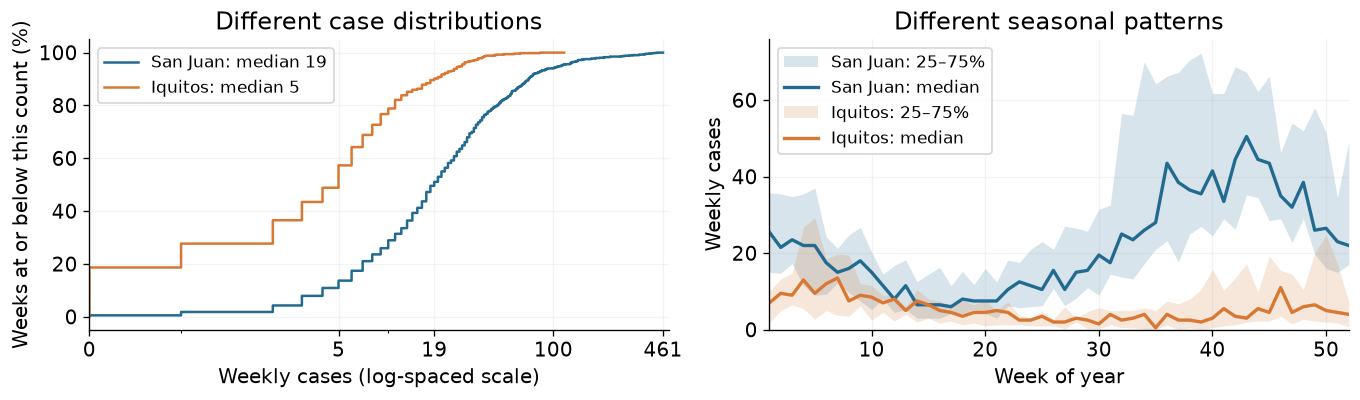

In [ ]:
from plot_utils import load_data, city_patterns, lag_evidence, validation_timeline, pipeline_diagram
eda = load_data()
city_patterns(eda)

The charts show differences in both the distribution of cases and the time of year when cases are higher. 

**Decision:** perform EDA separately, then prepare and fit a model for each city.

## Missing Data

**Missing measurements across all inputs**:

In [7]:
data.isna().sum().sort_values(ascending=False).head()

ndvi_ne                    194
ndvi_nw                     52
station_diur_temp_rng_c     43
station_avg_temp_c          43
station_precip_mm           22
dtype: int64

**Vegetation (NDVI) have the most missing values**

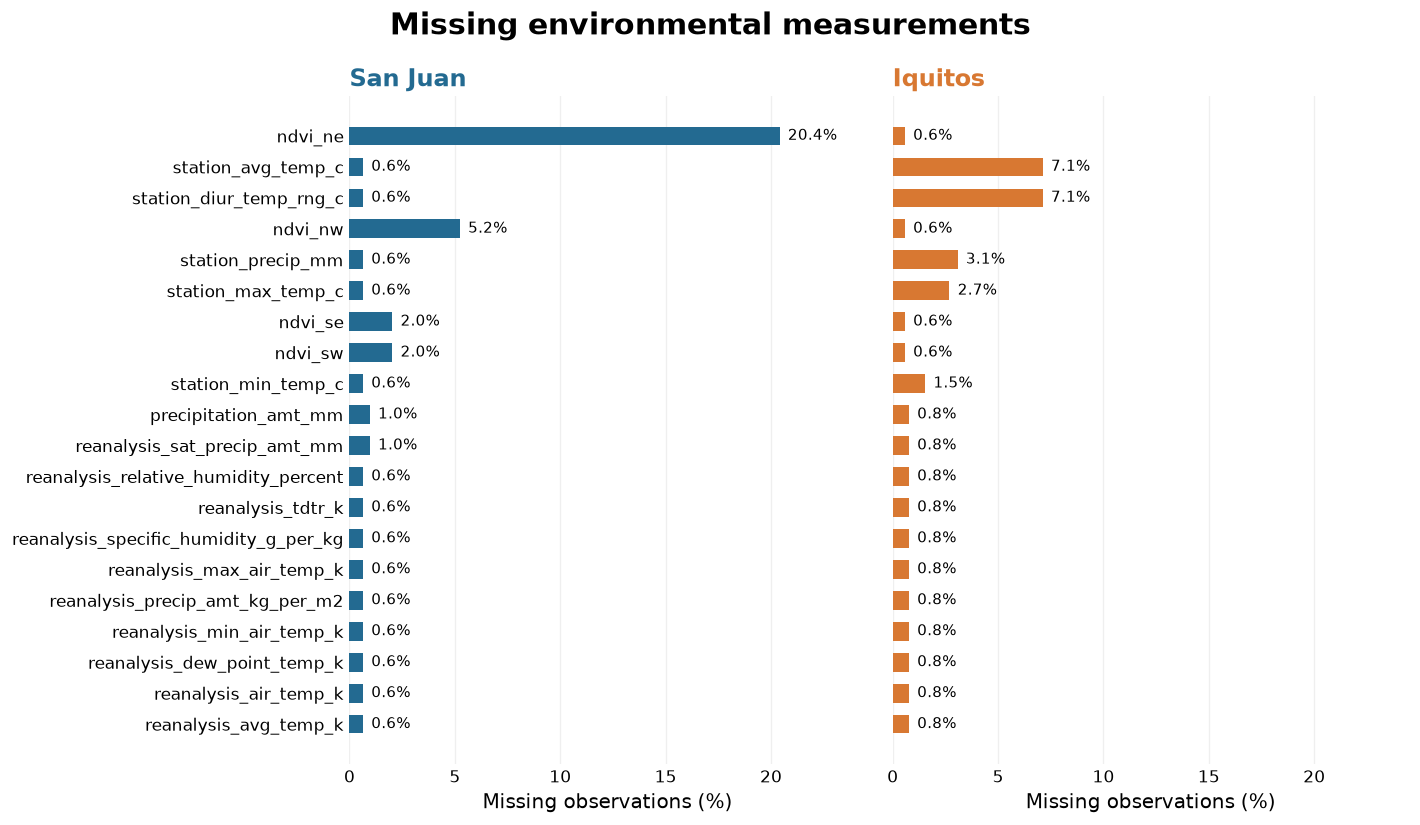

In [ ]:
from plot_utils import ndvi_missing_summary, missingness_by_city

missingness_by_city(eda)

Compare the missing percentage and longest consecutive gap within each city:

In [ ]:
ndvi_missing_summary(eda)

Missing (%)  Longest gap (observations)
City     Vegetation feature                                         
San Juan ndvi_ne                    20.4                          15
         ndvi_nw                     5.2                          15
         ndvi_se                     2.0                          14
         ndvi_sw                     2.0                          14
Iquitos  ndvi_ne                     0.6                           1
         ndvi_nw                     0.6                           1
         ndvi_se                     0.6                           1
         ndvi_sw                     0.6                           1

**How we fill missing measurements:**

- **San Juan vegetation:** use the typical value (median) for the same week of the year, learned from the training data. If unavailable, use the overall training median for that measurement.
- **Iquitos vegetation:** estimate missing values between the nearest available measurements before and after the gap (linear interpolation).
- **Other weather measurements in both cities:** use the same interpolation approach for gaps between known values.

Why treat San Juan vegetation differently? 
- Its long gaps would otherwise repeat an old value for many weeks if we used forward-fill.

## 6. Weather history

**Why look at earlier weather?**

- **The effect may take time:** weather conditions today may be linked to dengue cases several weeks later. Earlier measurements help the model capture this delay.
- **Good conditions may build up:** our hypothesis is that several weeks of suitable warmth and moisture allow mosquito populations to grow more than one favourable week alone.
- **Duration matters:** rolling averages of temperature and humidity, and rainfall totals, describe whether conditions stayed favourable over several weeks.

**What did we find and use?**

- **In San Juan:** temperature and specific humidity have stronger positive associations with current cases around **8–10 observations earlier** than in the same week. The pattern differs in Iquitos.
- **Weather lags:** include measurements from **1, 2, 4, 8, 10, 20 and 26 observations earlier**.
- **Rolling summaries:** describe weather over the previous **4–26 observations** to capture sustained conditions.
- **Benchmark motivation:** DrivenData also suggests exploring earlier weather to address a mismatch in the timing of predicted cases. [Benchmark discussion](https://drivendata.co/blog/dengue-benchmark/)


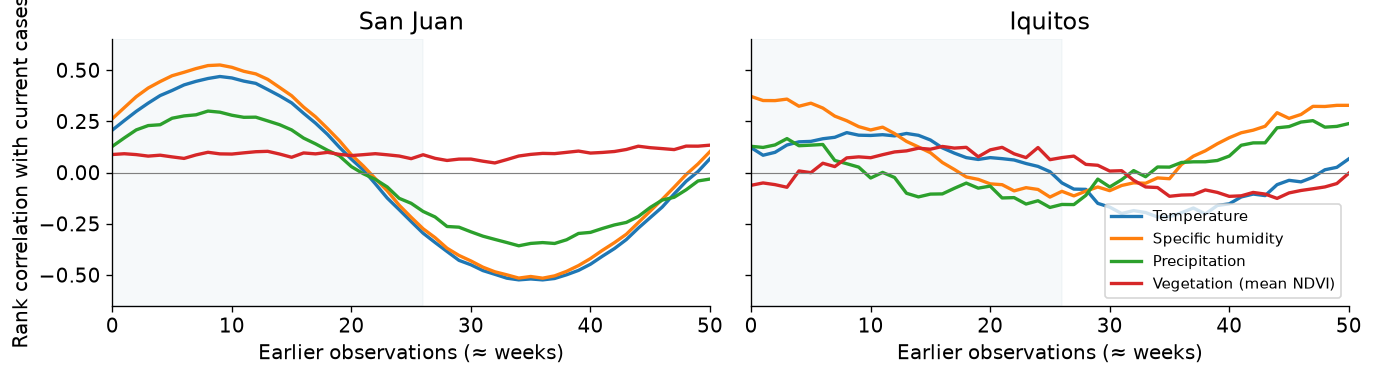

In [14]:
lag_evidence(eda)

## 7. Cross-validation

- **Keep time order:** train on earlier weeks and validate on later weeks.
- **Repeat five times per city:** predict the next **52 observations** (about one year), using more training history each round.
- **Keep a final check:** set aside the last **52 observations** as a separate holdout.
- **Choose settings using CV MAE:** lower average error is better. Then report the holdout error.
- **Why:** a random split would mix earlier and later periods. Chronological CV asks a question closer to the competition task.

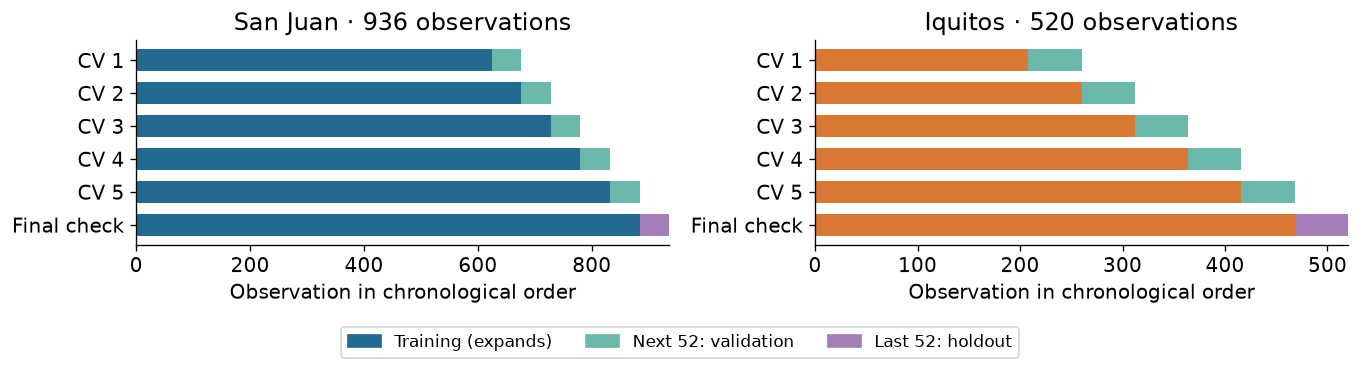

In [15]:
validation_timeline(eda)

## 8. Pipelines

- **One process:** fill gaps, add weather history, prepare inputs and train the model.
- **Avoid data leakage:** learn filling rules, scaling and feature selection from training data only.
- **Fair validation:** keep validation case counts out of training.
- **Consistent predictions:** reuse the same fitted preparation for new data.

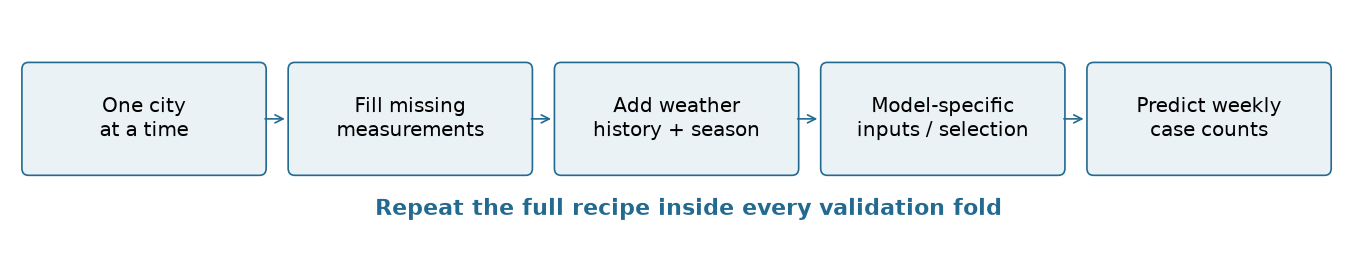

In [16]:
pipeline_diagram()